# MCMC example

This notebook will fit to differential cross section data for $\omega$ and $\phi$ photoproduction.

## 1. Load data and packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import photoproduction model
from photoproductionmodel import *

# Import data sets
omega_data = read_csv("selected_omega_dataset.csv")
phi_data = read_csv("selected_phi_dataset.csv")

## 2. Define priors

In [3]:
# Priors on variable parameters
#  params[0] = g_pi_NN
#  params[1] = g_eta_NN
#  params[2] = Lambda_pi_NN
#  params[3] = Lambda_eta_NN
#  params[4] = Lambda_pi_gam_omega
#  params[5] = Lambda_eta_gam_omega
#  params[6] = Lambda_pi_gam_phi
#  params[7] = Lambda_eta_gam_phi
#  params[8] = b_Pom_omega_omega
#  params[9] = b_Pom_phi_phi
#  params[10] = B_omega (form factor slope)
#  params[11] = B_phi (form factor slope)
#  params[12] = alpha_Pom (Pomeron trajectory)
#  params[13] = a_Pom_omega_omega
#  params[14] = a_Pom_phi_phi 
#  params[15] = Lambda_pi_gam_rho
#  params[16] = Lambda_eta_gam_rho
#  params[17] = b_Pom_rho_rho
#  params[18] = a_Pom_rho_rho
#  params[19] = B_rho (form factor slope)

# Central values at 0 and errors at 1e5 (large number) do not contribute to prior
cent_values = np.array([13, 4, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0, 0, 0, 0, 0, 0, 0, 0.8, 0.8, 0, 0, 0])
prior_errors = np.array([1, 1, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 1e5, 1e5, 1e5, 1e5, 1e5, 1e5, 1e5, 0.2, 0.2, 1e5, 1e5, 1e5])

def chi_sq_priors(params):

    # Require Eq. (A8) from Ben Othman 2311.00043 
    # a_PVV > 0 and b_PVV + 2 * mV^2 * a_PVV > 0
    # for all V = omega, phi, rho
    a_Pom_omega_omega, b_Pom_omega_omega = params[13], params[8]
    a_Pom_rho_rho, b_Pom_rho_rho = params[18], params[17]
    a_Pom_phi_phi, b_Pom_phi_phi = params[14], params[9]

    # If any inequalities not satisfied, return infinity
    if (a_Pom_omega_omega < 0) or (a_Pom_rho_rho < 0) or (a_Pom_phi_phi < 0):
        return np.inf
    elif (2*m_omega**2 * a_Pom_omega_omega + a_Pom_omega_omega < 0):
        return np.inf
    elif (2*m_phi**2 * a_Pom_phi_phi + b_Pom_phi_phi < 0):
        return np.inf
    elif (2*m_rho**2 * a_Pom_rho_rho + b_Pom_rho_rho < 0):
        return np.inf

    # Else impose Gaussian prior on parameters
    else:
        return np.sum((params - cent_values)**2/prior_errors**2)



## 3. Comparison to data

The likelihood function is $P = e^{- \chi^2/2}$ where the total $\chi^2$ as a sum of four terms:

$$\chi^2 = \chi^2_{\gamma p \to \omega p} + \chi^2_{\gamma p \to \phi p} + \chi^2_{\gamma p \to {\rm all}} + \chi^2_{\rm priors}$$

- $\chi^2_{\gamma p \to \omega p}$ and $\chi^2_{\gamma p \to \phi p}$ are from exclusive differential cross section data for $\omega$ and $\phi$ photoproduction
- $\chi^2_{\rm priors}$ is for the priors as defined above
- $\chi^2_{\gamma p \to {\rm all}}$ is from the inclusive photon-proton scattering cross section at high energy (for all final states), given in Eq. (A9) in Ben Othman et al (2311.00043)

In [5]:
# chi^2 for omega photoproduction data for exclusive differential cross section (gamma p -> omega p)
def chi_sq_omega_data(params):
    
    W = omega_data['W']
    t = omega_data['t']
    obs = omega_data['dsigdt (mu barn/GeV^2)']
    err = omega_data['dsigdt error (mu barn/GeV^2)']

    # Calculate total error including a 10% systematic error
    sys_err = 0.1 * obs 
    err_tot = np.sqrt( err**2 + sys_err**2 )
    
    model = dsig_dt_omega(W,t,params)
    
    return np.sum((model - obs)**2/err_tot**2)

# chi^2 for phi photoproduction data for exclusive differential cross section (gamma p -> phi p)
def chi_sq_phi_data(params):
    
    W = phi_data['W']
    t = phi_data['t']
    obs = phi_data['dsigdt (mu barn/GeV^2)']
    err = phi_data['dsigdt error (mu barn/GeV^2)']
    
    # Calculate total error including a 10% systematic error
    sys_err = 0.1 * obs 
    err_tot = np.sqrt( err**2 + sys_err**2 )

    model = dsig_dt_phi(W,t,params)
    
    return np.sum((model - obs)**2/err_tot**2)

# chi^2 for photon-proton inclusive cross section (gamma p -> all final states)
def chi_sq_gamma_proton(params):

    # See Eq. (A9) from Ben Othman 2311.00043 
    
    # Data from H1 expt
    obs_H1, stat_error_H1, sys_error_H1 = 165, 2, 11 # mu barn
    tot_error_H1 = np.sqrt(stat_error_H1**2 + sys_error_H1**2)

    # H1 CM energy
    E_CM = 200 # GeV
    s_tot = E_CM**2

    # Model prediction for H1 energy
    model_H1 = sig_gamma_proton_tot(s_tot,params)

    # Data from Zeus expt
    obs_Zeus, stat_error_Zeus, sys_error_Zeus = 174, 1, 13 # mu barn
    tot_error_Zeus = np.sqrt(stat_error_Zeus**2 + sys_error_Zeus**2)

    # Zeus CM energy
    E_CM = 209 # GeV
    s_tot = E_CM**2

    # Model prediction for Zeus energy
    model_Zeus = sig_gamma_proton_tot(s_tot,params)

    return (model_H1 - obs_H1)**2 / tot_error_H1**2 + (model_Zeus - obs_Zeus)**2 / tot_error_Zeus**2
    
# Total chi^2
def chi_sq_tot(params):
    return chi_sq_omega_data(params) + chi_sq_phi_data(params) + chi_sq_priors(params) + chi_sq_gamma_proton(params)

# Test on default_params
chi_sq_tot(default_params)

np.float64(1428.4638252092393)

## 4. MCMC scan

Basic Metropolis algorithm

In [17]:
# MCMC scan

# First parameter point
x0 = default_params
chi_sq_old = chi_sq_tot(x0)

# Initialize chain
num = 1000
num_params = len(x0)
cov = np.diag([1e-4] * num_params)
x = [x0]

# Metropolis
for i in range(0,num-1):
    
    x_old = x[-1]
    x_new = np.random.multivariate_normal(x_old,cov)
    chi_sq_new = chi_sq_tot(x_new)

    # Acceptance ratio
    A = np.exp(-0.5*(chi_sq_new-chi_sq_old))

    # Acceptance/rejection step
    r = np.random.rand()
    if A > r:
        
        # Accept
        x.append(x_new)
        chi_sq_old = chi_sq_new
        
    else:

        # Reject
        x.append(x_old)

# Convert chain to numpy array
x = np.array(x)        
    

## 5. MCMC results

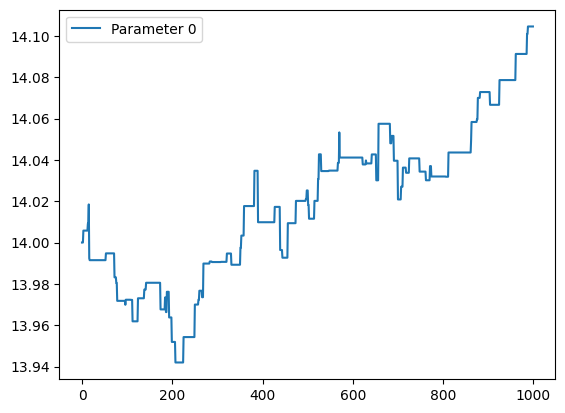

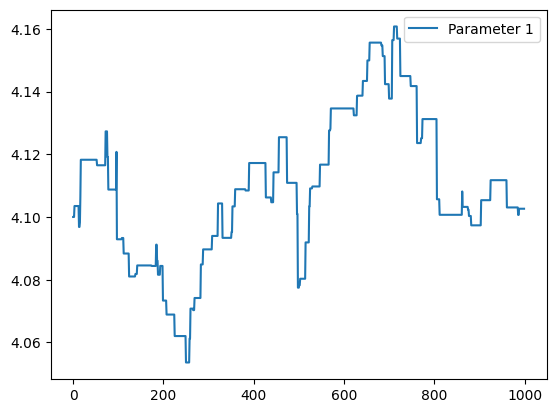

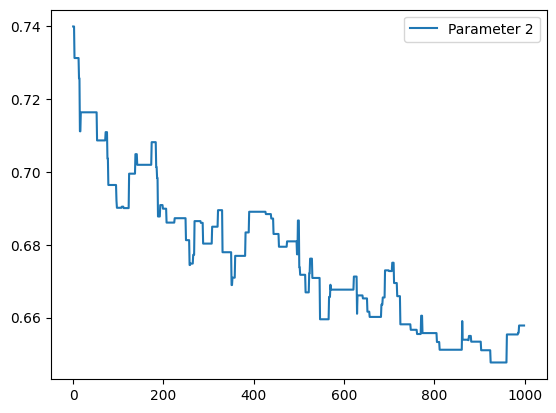

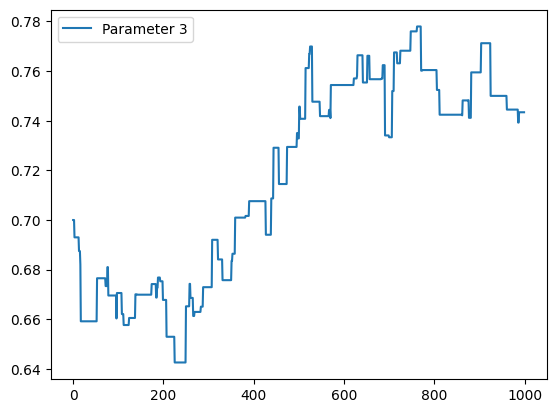

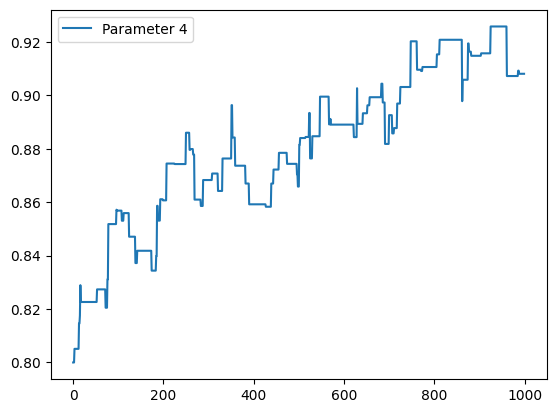

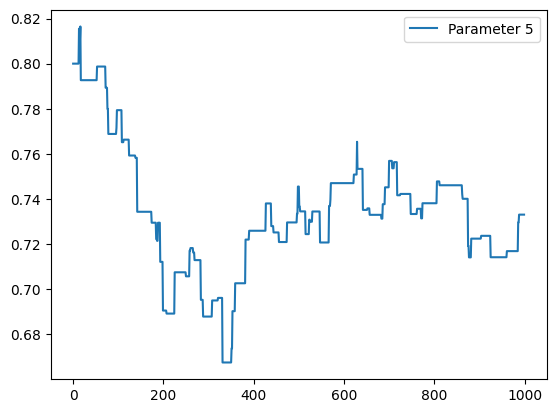

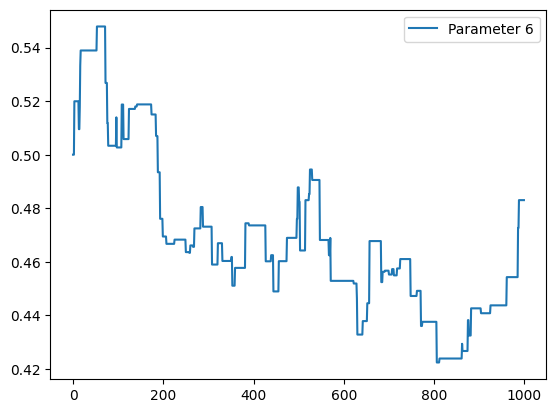

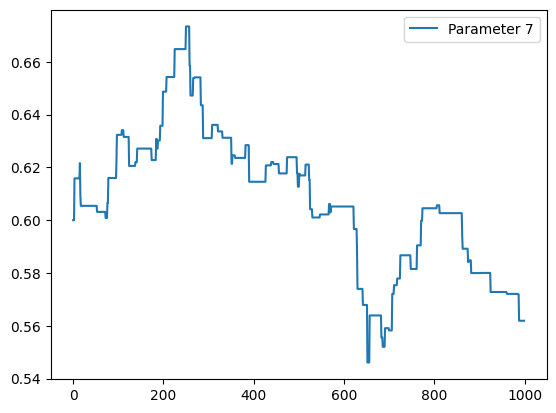

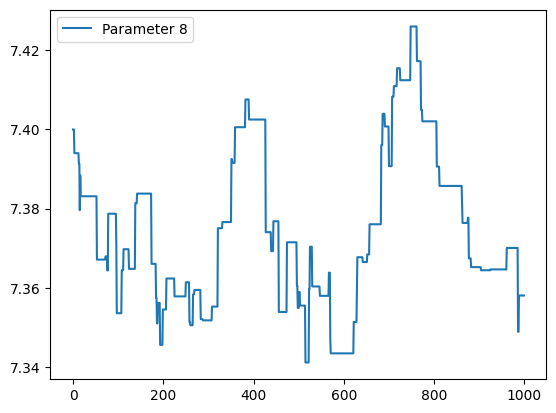

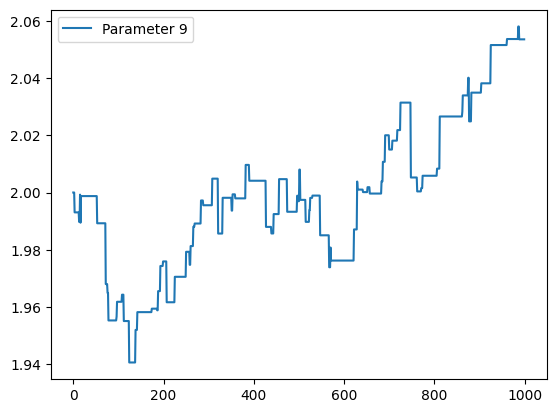

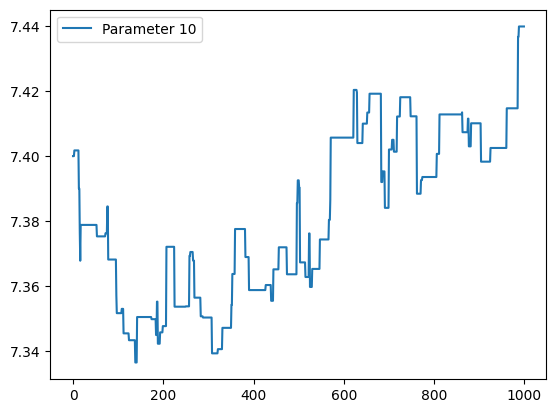

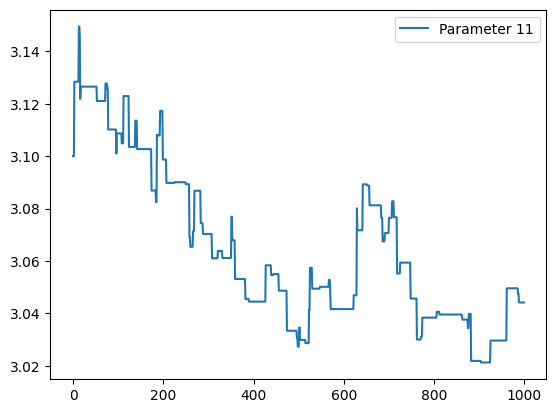

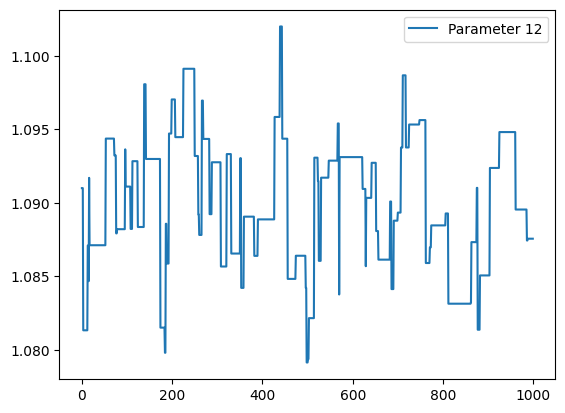

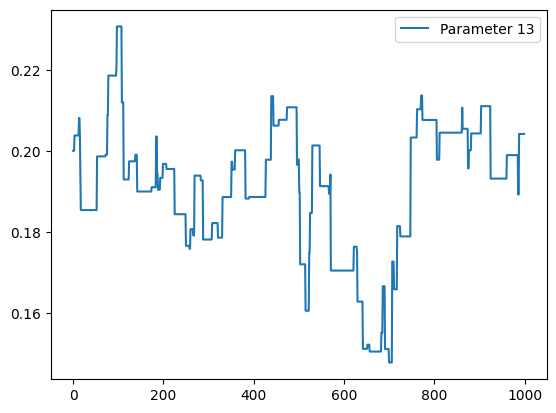

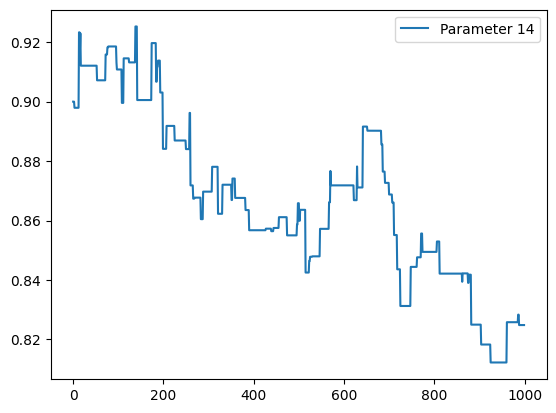

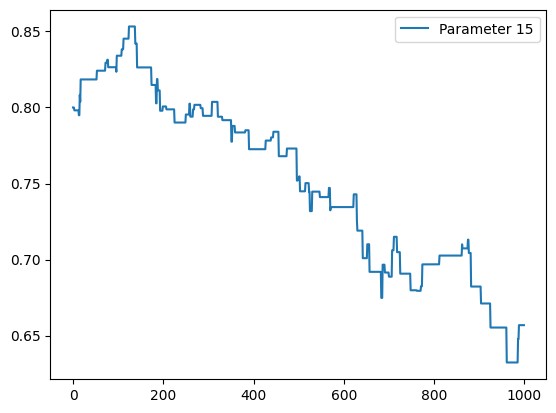

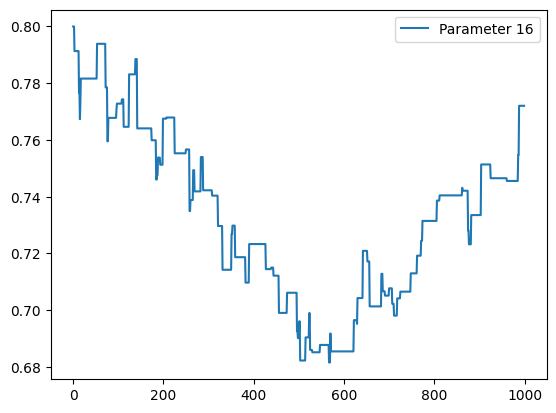

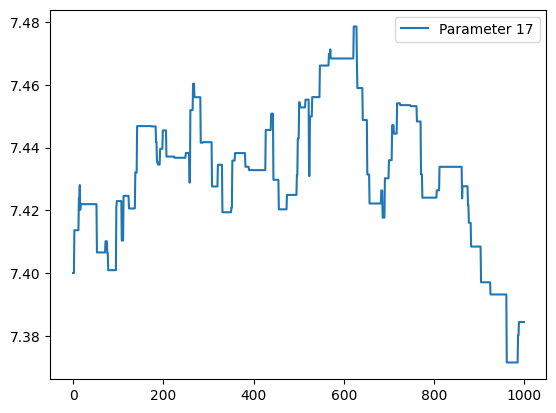

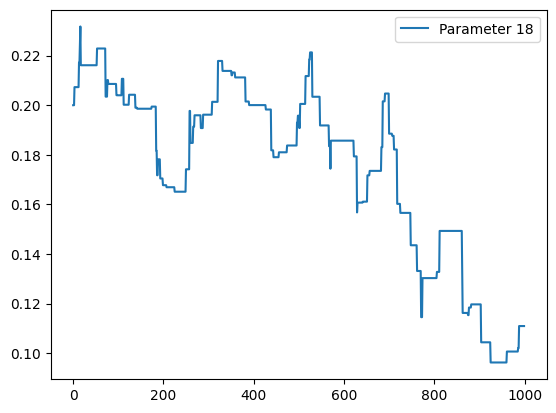

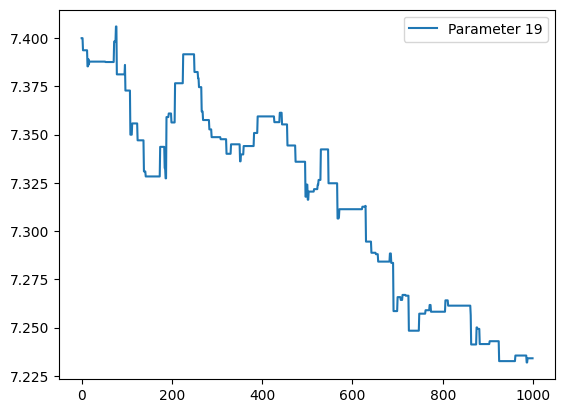

In [26]:
# Trace plots

for i in range(num_params):
    plt.plot(x[:,i], label=f'Parameter {i}')
    plt.legend()
    plt.show()